## 1. Importación de Librerías
Se importan las librerías necesarias para el análisis:
- **pandas** y **numpy**: Manipulación de datos
- **matplotlib** y **seaborn**: Visualización de gráficos
- **sklearn**: Preprocesamiento, modelos y métricas de ML

In [31]:
# ===============================
# 📦 IMPORTACIÓN DE LIBRERÍAS
# ===============================

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Reducción de dimensionalidad
from sklearn.decomposition import PCA

# Modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

# Métricas
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

# Configuración opcional de gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,6)

## 2. Carga y Exploración de Datos
Se cargan los datos del archivo CSV del dataset de hongos Agaricus-Lepiota. Se visualiza:
- Dimensiones del dataset y primeras filas
- Tipos de datos y valores nulos
- Cantidad de valores únicos por columna

In [32]:

column_names = [
    "class", "cap-shape", "cap-surface", "cap-color", "bruises",
    "odor", "gill-attachment", "gill-spacing", "gill-size",
    "gill-color", "stalk-shape", "stalk-root",
    "stalk-surface-above-ring", "stalk-surface-below-ring",
    "stalk-color-above-ring", "stalk-color-below-ring",
    "veil-type", "veil-color", "ring-number", "ring-type",
    "spore-print-color", "population", "habitat"
]

df = pd.read_csv("agaricus-lepiota.data", header=None, names=column_names)
# Vista general
print("Shape:", df.shape)
display(df.head())

# Tipos y nulos
print(df.info())
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Valores únicos
print("\nValores únicos por columna:")
for col in df.columns:
    print(col, ":", df[col].nunique())

Shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

## 3. Limpieza de Datos
Se eliminan columnas con varianza nula (columnas constantes) que no aportan información útil para el modelo.

In [33]:
cols_constantes = [col for col in df.columns if df[col].nunique() <= 1]
df = df.drop(columns=cols_constantes)

print("Columnas eliminadas:", cols_constantes)

Columnas eliminadas: ['veil-type']


## 4. Separación de Features y Target
Se separan las características (X) de la variable objetivo (y). La variable objetivo es "class" (comestible/tóxico).

In [34]:
target = "class"  # cambia por tu variable objetivo

X = df.drop(columns=[target])
y = df[target]

## 5. Preprocesamiento de Datos
Se aplica un pipeline de preprocesamiento:
- Variables numéricas: se mantienen sin cambios
- Variables categóricas: se codifican usando One-Hot Encoding (eliminando la primera categoría para evitar multicolinealidad)

In [35]:
cat_cols = X.select_dtypes(include=["object", "string"]).columns
num_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

## 6. Escalado y Reducción de Dimensionalidad
Se escalan los datos normalizados y se aplica PCA (Análisis de Componentes Principales) para reducir a 2 componentes para visualización. Se muestra la varianza explicada por cada componente.

In [36]:
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X_processed)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada:", pca.explained_variance_ratio_)

Varianza explicada: [0.09437127 0.07230109]


## 7. Visualización de PCA
Se visualiza el espacio bidimensional generado por PCA, coloreando según la variable objetivo (comestible vs tóxico) para observar la separabilidad de las clases.

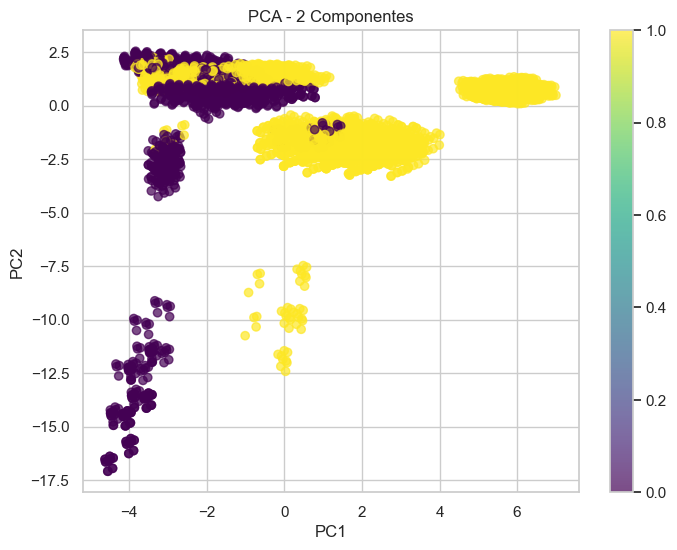

In [37]:
y_numeric = y.map({'e': 0, 'p': 1})
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_numeric, cmap="viridis", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - 2 Componentes")
plt.colorbar()
plt.show()

## 8. Entrenamiento y Evaluación con Random Forest
Se divide el dataset en entrenamiento/prueba (80/20), se entrena un Random Forest y se evalúa su desempeño con métricas de precisión (accuracy y reporte de clasificación).

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           e       1.00      1.00      1.00       843
           p       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



## 9. Análisis del Impacto de PCA en Random Forest
Se evalúa el desempeño del Random Forest variando el número de componentes de PCA (2 a 20) para determinar cuántas dimensiones son necesarias manteniendo buena precisión.

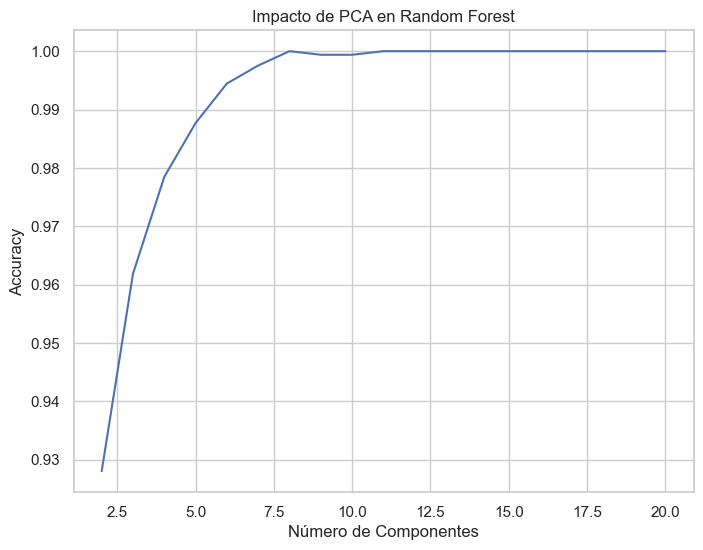

In [39]:
accuracies = []

for n in range(2, 21):
    pca = PCA(n_components=n)
    X_pca_n = pca.fit_transform(X_scaled)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_pca_n, y, test_size=0.2, random_state=42
    )
    
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(range(2,21), accuracies)
plt.xlabel("Número de Componentes")
plt.ylabel("Accuracy")
plt.title("Impacto de PCA en Random Forest")
plt.show()

## 10. Análisis del Impacto de PCA - Verificación
Repetición del análisis anterior para confirmar los resultados del impacto del número de componentes PCA en la precisión del modelo.

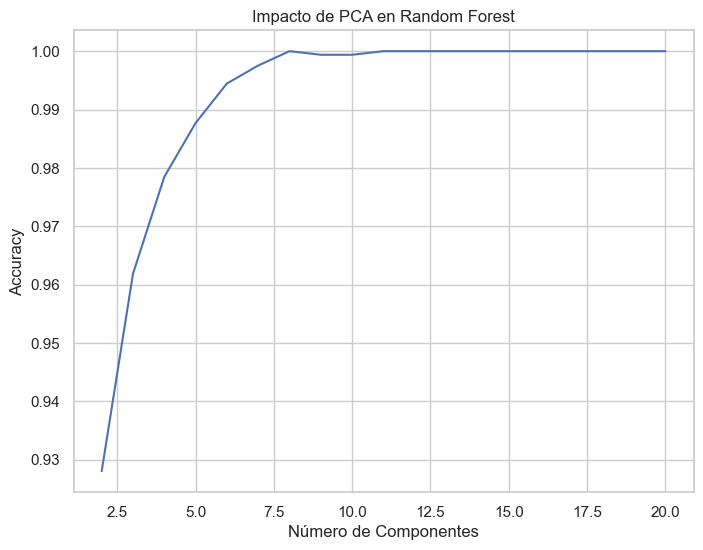

In [40]:
accuracies = []

for n in range(2, 21):
    pca = PCA(n_components=n)
    X_pca_n = pca.fit_transform(X_scaled)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_pca_n, y, test_size=0.2, random_state=42
    )
    
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(range(2,21), accuracies)
plt.xlabel("Número de Componentes")
plt.ylabel("Accuracy")
plt.title("Impacto de PCA en Random Forest")
plt.show()

## 11. Método del Codo para Determinar Número Óptimo de Clusters
Se aplica K-Means con diferentes números de clusters (1 a 10) y se visualiza la inercia (suma de distancias cuadradas) para identificar el punto de inflexión (codo) que sugiere el número óptimo de clusters.

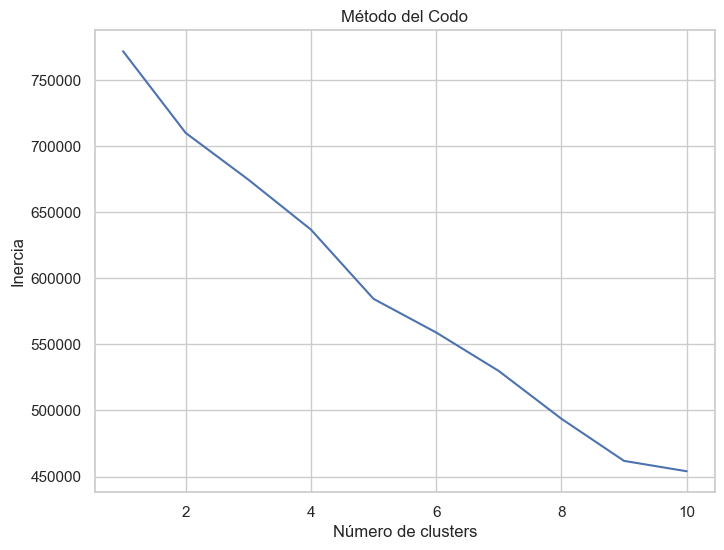

In [41]:
inertias = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias)
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

## 12. Aplicación de K-Means con 3 Clusters
Se entrena K-Means con 3 clusters en el espacio escalado y se visualiza el resultado en el espacio PCA bidimensional, asignando colores a cada cluster.

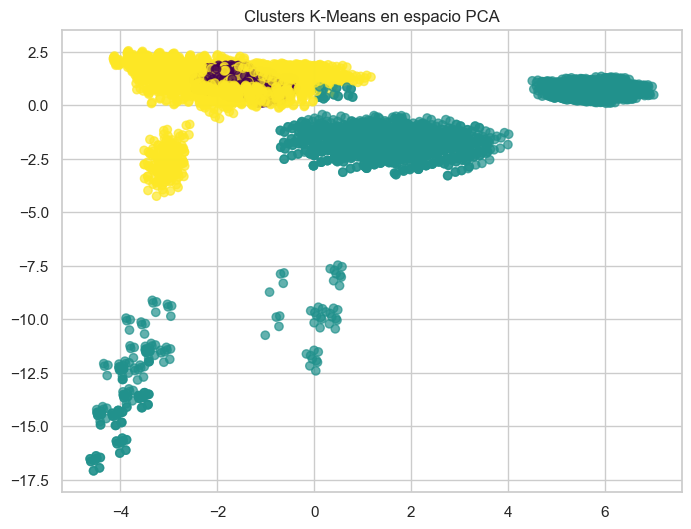

In [42]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis", alpha=0.7)
plt.title("Clusters K-Means en espacio PCA")
plt.show()

## 13. Comparación de Clusters con la Variable Objetivo
Se genera una tabla de contingencia (crosstab) cruzando los clusters generados por K-Means con la variable objetivo, para evaluar si los clusters capturan la estructura natural de las clases (comestible/tóxico).

In [43]:
pd.crosstab(clusters, y)

class,e,p
row_0,,
0,1728,0
1,288,3100
2,2192,816
